<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_9)_RNNs_in_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 9)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### This notebook revises basics of Recurrent Neural Networks and their Applications in NLP


### Recurrence

* Recurrence is a mathematical relationship that expresses the current value of a variable or a function in terms of its previous values
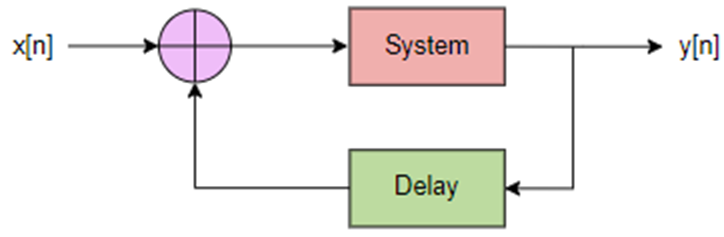

A system with a feedback path, implementing recurrence.

### Recurrent Neural Networks (RNNs)

* RNNs have memory to consider previous inputs along with the current input to produce the output.
* In RNNs, we have **recurrent units** that process sequential time-varying data.
* We can create a minimal recurrent unit by connecting the output of the current **timestep** (a single occurrence of the recurrent unit) to the input of the next timestep.
* The time dimension of the input data is modeled in RNNs because we want to learn temporal and long-term dependencies in data.


> An RNN given below features one recurrent unit for input $x$, output $y$, system (hidden) $h$, and parameters $A, B$, and $C$.

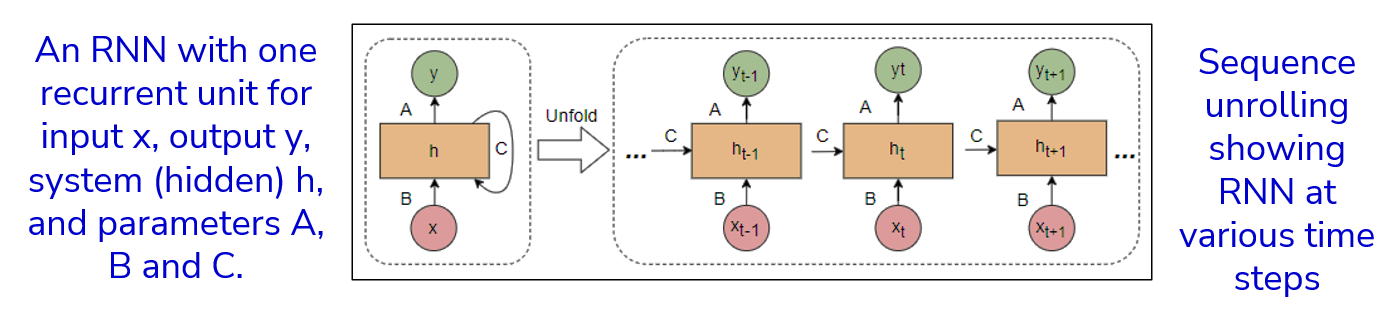


* Sequence unrolling, a concept in RNNs, visualizes RNNs as multiple copies of feedforward networks, each passing its output to the next network at various time steps.

* Generally, each hidden layer has its activation function and network parameters to be learned.
* However, an RNN standardizes various activation functions and edge weights such that each hidden layer has the same parameters.
* Therefore, instead of having multiple layers, an RNN creates one hidden layer and loops over it multiple times.

### Types of RNNs

Based on the number of inputs and outputs, RNNs have four types:
* **One-to-one**: These single input/single output networks can predict time series data such as stock price predictions and weather predictions, and classify images.
* **One-to-many**: These single input/multiple outputs networks find their applications in image captioning and music generation.
* **Many-to-one**: These multiple (sequence) inputs/single output networks can analyze sentiments (many words/sentences to single sentiment).
* **Many-to-many**: These multiple (sequence) inputs/multiple outputs networks are used for named entity recognition and machine translation (translate the input data of one language into another language).
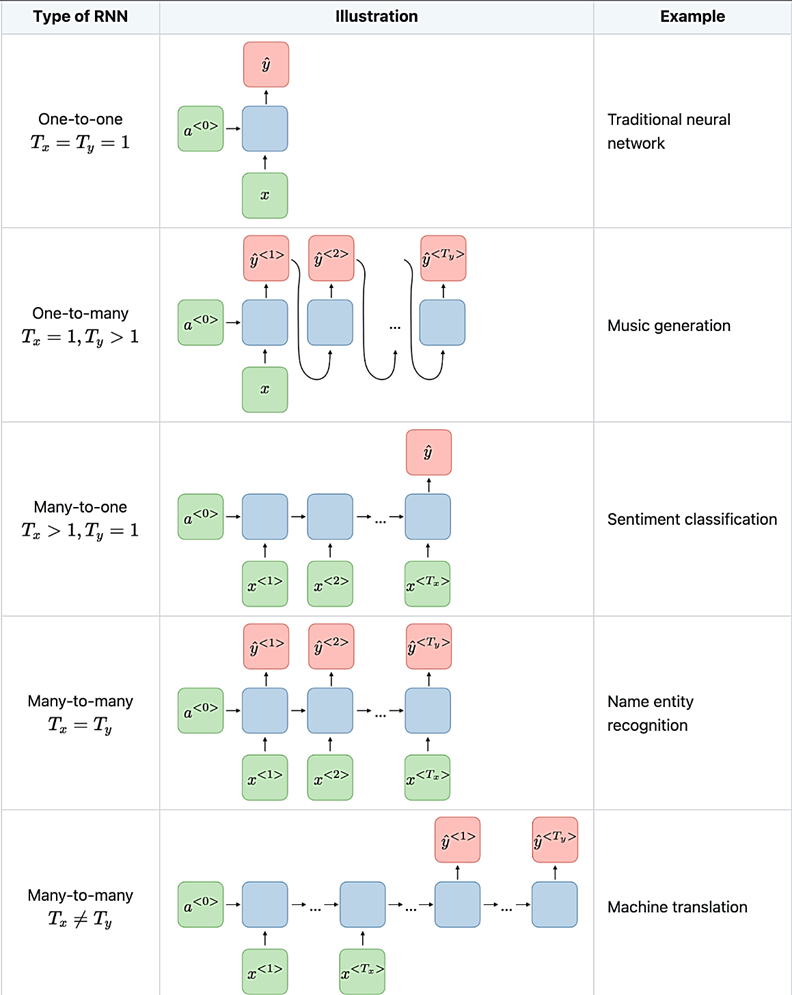

### One-to-One

- Spam/Ham email prediction using a single numerical vector representation of the email (length, word count, keyword frequency).
- Image classification

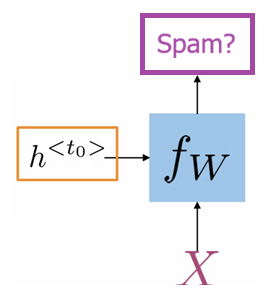

### One-to-Many
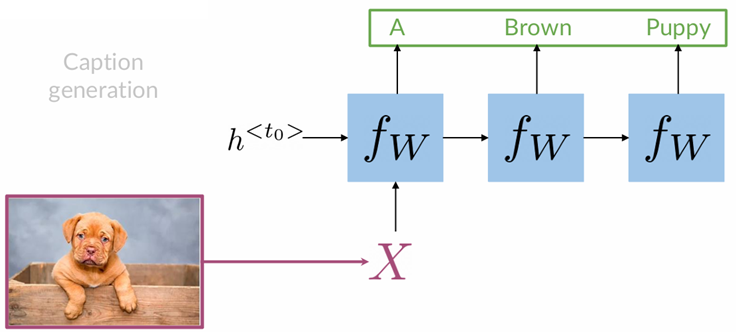

### Many-to-One

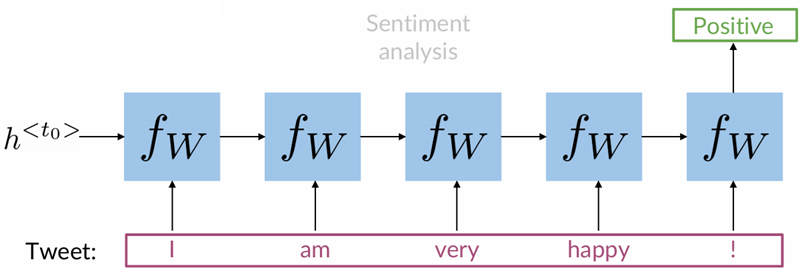

### Many-to-Many

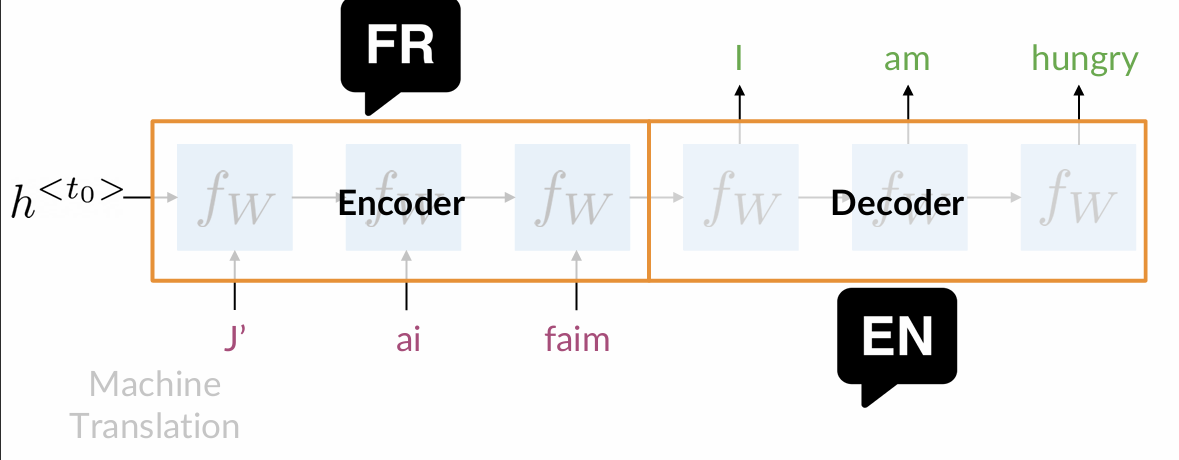

### Traditional Language Models (N-grams)
Before RNNs became popular, $N$-gram models were used for language modeling tasks like machine translation and text generation.

$N$-grams are sequences of $N$ consecutive words from a text. The probability of a word is calculated based on the previous $N-1$ words.

1. **Bigrams ($N=2$)**: Uses 1 previous word
   $$P(w_2|w_1) = count(w_1, w_2) / count(w_1)$$

2. **Trigrams ($N=3$)**: Uses 2 previous words
   $$P(w_3|w_1, w_2) = count(w_1, w_2, w_3) / count(w_1, w_2)$$

> Formula for a sequence of words:
$$ P(w_1, w_2, \dots, w_n) =
\prod_{i=1}^{n} P\big(w_i \mid w_1, w_2, \dots, w_{i-1}\big)$$
- For 3 words: $$P(w_1, w_2, w_3) = P(w_1) × P(w_2|w_1) × P(w_3|w_2)$$

### Problems with $N$-grams
$N$-grams are:
- ✓ **Simple and interpretable**
- ✓ **Fast to compute**

But they are:
1. **Memory Intensive**: Requires storing counts for all possible $N$-gram combinations
2. **Long Dependencies**: Can't capture relationships between words far apart
3. **Sparsity**: Many $N$-grams may never appear in training data
4. **Scaling Issues**: Larger $N$-grams exponentially increase memory requirements


**Solution**: Different types of RNNs are the preferred alternative because RNNs look at a large number of previous words, not just the last $N$ words. This allows them to capture long-range dependencies while using shared parameters.

### Summary: RNN Advantages

| Feature | N-grams | RNNs |
|---------|---------|------|
| Long-range dependencies | ❌ Limited | ✓ Yes |
| Memory usage | ❌ High | ✓ Lower |
| Parameter sharing | ✗ No | ✓ Yes |
| Sequence length | Fixed | Variable |
| Training complexity | ✓ Simple | Moderate |

### A Simple RNN

- How RNNs propagate information (Through time!)
- How RNNs make predictions

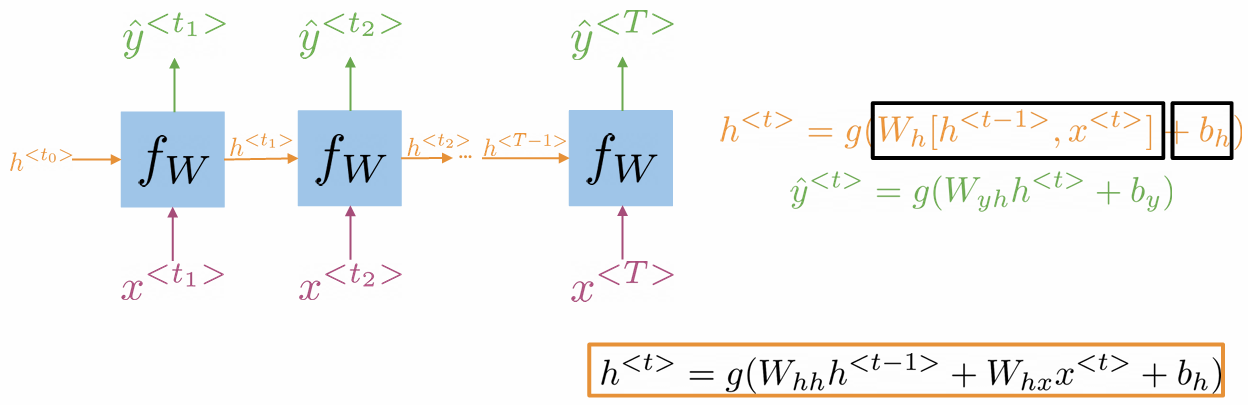

### A Simple RNN

- Hidden states propagate information through time
- Basic recurrent units use two inputs at each time:      
   - $h^{<t-1>}$
   - $x^{<t>}$               

- In the figure below, $\hat{y}^{<t>}$ is computed using $h^{<t>}$, $W_{yh}$ and $b_y$
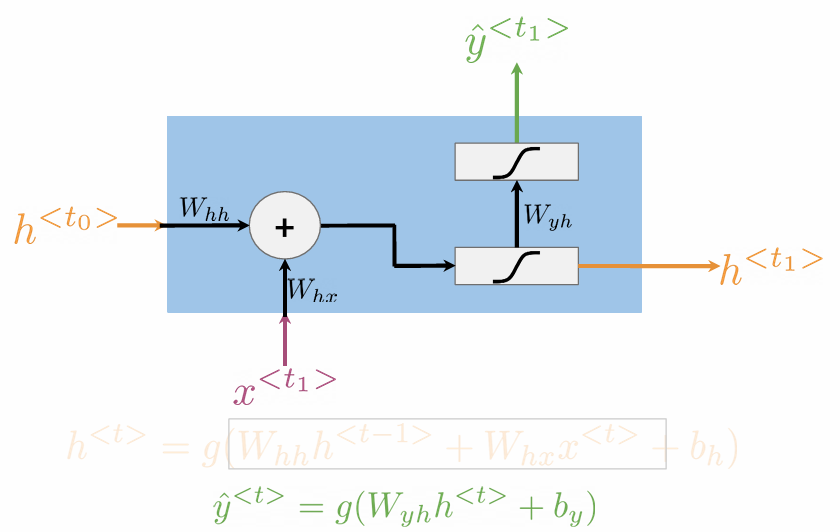

### RNN Basic Structure

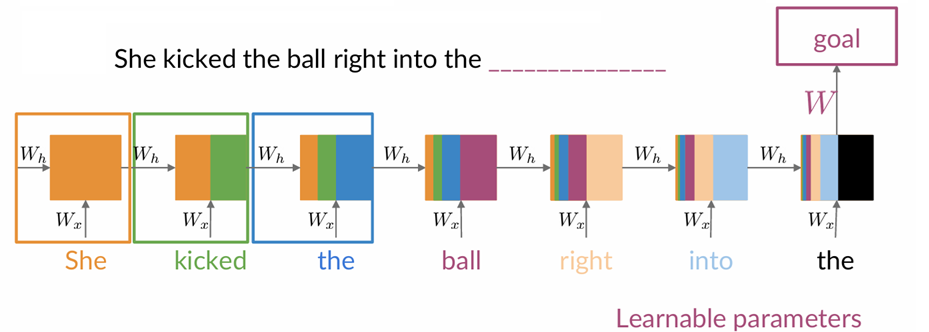


#### Input sequence: She kicked the ball right into the __________

Processing in RNN:
1. Process 'She' → hidden state $h^0$
2. Process 'kicked' + $h^0$ → hidden state $h^1$
3. Process 'the' + $h^1$ → hidden state $h^2$
...
N. Process 'the' + $h^{(n-1)}$ → hidden state $h^n$ → predict next word


#### Key Components

1. $W_x$: Weight matrix for input
2. $W_h$: Weight matrix for hidden state (recurrent)
3. $b_h$: Bias for hidden layer
4. Activation function*: Usually tanh or ReLU

#### Why Parameter Sharing?

The same weights ($W_x$, $W_h$) are used at each time step. This:
- Reduces the number of parameters
- Allows the model to process sequences of any length
- Captures similar patterns at different positions

### Cost / Loss Functions in RNNs

- Loss is for a single example, the overall loss for a dataset batch is the cost function

- Cross Entropy Loss
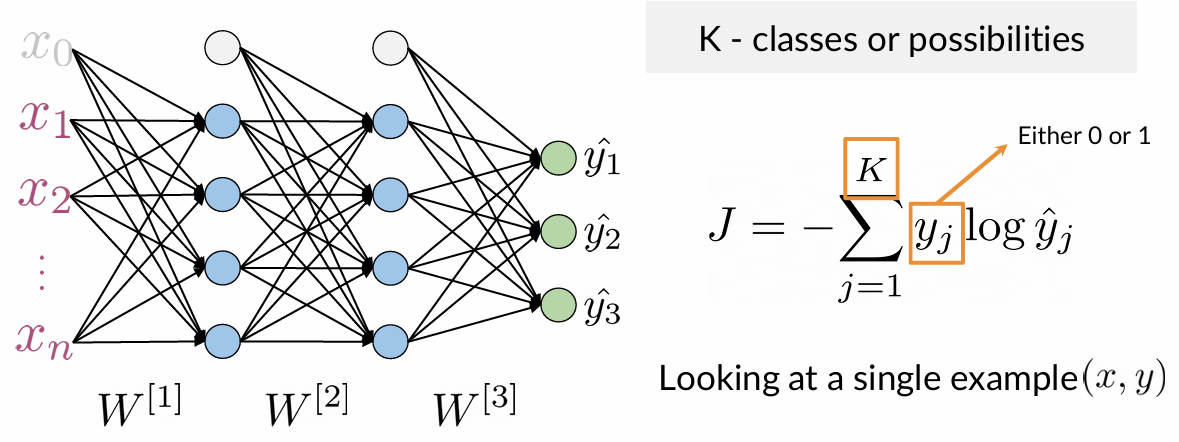




### Cost / Loss Functions in RNNs

- For RNNs the loss function is computed by taking average through time.

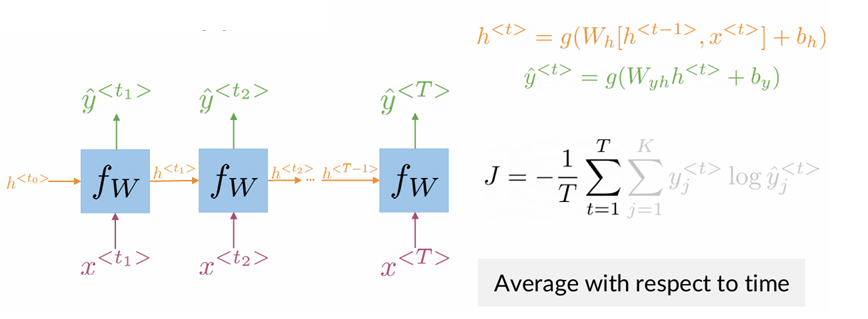

### Backpropagation Through Time in RNNs

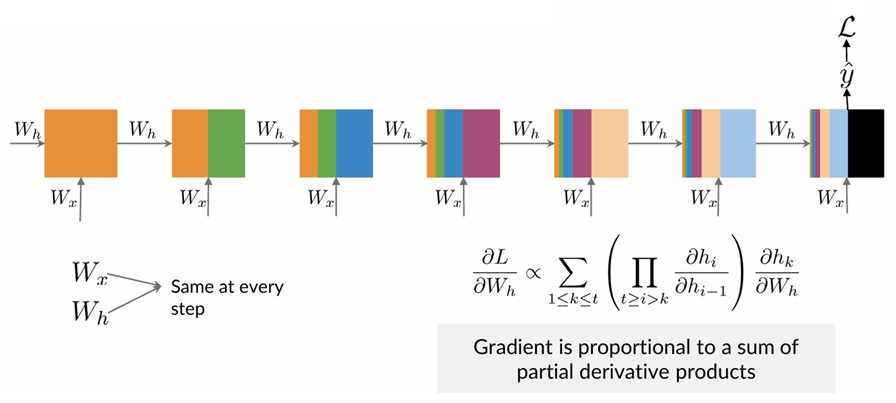

### Backpropagation Through Time in RNNs

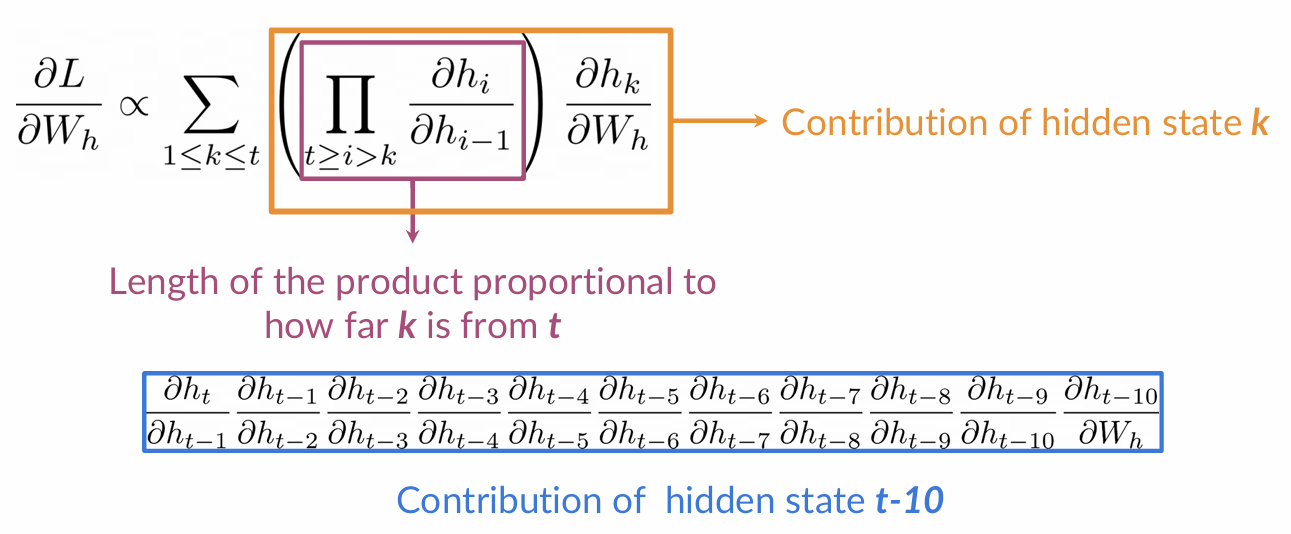

### Backpropagation Through Time in RNNs

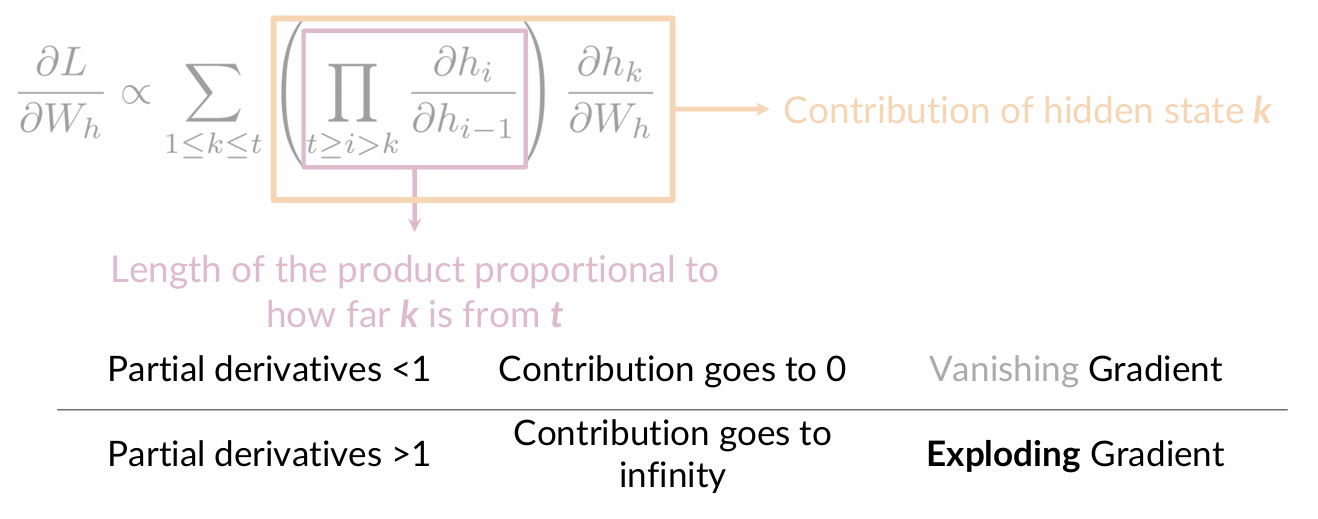

### Solving Vanishing & Exploding Gradients (RNNs)

Training deep networks (especially RNNs) often leads to:

* **Vanishing gradients** → gradients → 0 → no learning in early layers
* **Exploding gradients** → gradients → ∞ → unstable updates

### Possible Solutions

1.   Identity RNN with ReLU Activation.
Initialize the recurrent weight matrix as an **identity matrix** $W_h = I$
and use **ReLU activation** instead of sigmoid/tanh because ReLU avoids saturation (unlike tanh/sigmoid).
2.   Gradient Clipping: Limit the magnitude of gradients during backpropagation. (Prevents **exploding gradients**)
3. Skip Connections (Residual Connections): Add direct connections across layers or time steps.
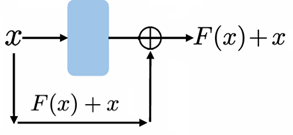
$$h_t = f(h_{t-1}, x_t) + h_{t-1}$$
   * Skip connections provide **shortcut paths** for gradients
   * Reduces dependency on long chains of multiplications
   * In Backpropagation, gradients have a direct path via identity. So, instead of:
     $$\frac{\partial L}{\partial h_{t-1}} = \frac{\partial L}{\partial h_t} \cdot W_h$$
    We get:
     $$\frac{\partial L}{\partial h_{t-1}} =
\frac{\partial L}{\partial h_t} \cdot (W_h + I)$$


#### Summary Table

| Method              | Solves    | Key Idea                       |
| ------------------- | --------- | ------------------------------ |
| Identity RNN + ReLU | Vanishing | Preserve gradient flow         |
| Gradient Clipping   | Exploding | Limit gradient magnitude       |
| Skip Connections    | Both      | Provide shortcut for gradients |


### Limitations of RNNs

* Due to recurrence relationships between input and output, an RNN can’t use future data to compute the current output.
* Furthermore, RNNs are slow and hard to train because they suffer from:
    * **The vanishing gradient problem**: Which makes the values of gradients too small to be useful in the training.
    * **The exploding gradient problem**: Which results in large gradient values, which in turn make model parameters exponentially large.

### Long Short-Term Memory (LSTM)
- Long Short-Term Memory (LSTM) is a specialized Recurrent Neural Network (RNN) architecture designed to learn long-term dependencies in sequential data,
- It overcomes the vanishing gradient problem of traditional RNNs.
- By using a gated memory cell, LSTMs retain or forget information over long sequences.
-LSTMs Applications
   - Time series forecasting
   - Speech recognition
   - Language translation

  


### Long Short-Term Memory (LSTM)

LSTM learns when to remember and when to forget
- Basic anatomy
   - A cell state
   - A hidden state
   - Multiple gates
- Gates allow gradients to avoid vanishing and exploding

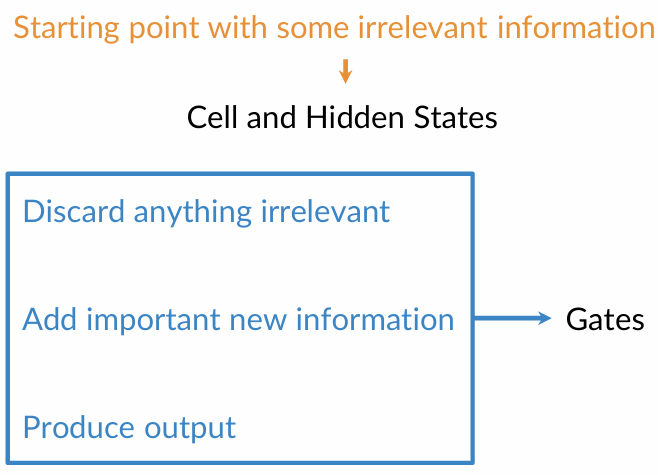

### Gates in LSTM

- LSTMs offer a  solution to vanishing gradients.
- It has a cell and three gates:
   1. Forget Gate: information that is no longer important
   2. Input Gate: information to be stored
   3. Output Gate: information to use at current step
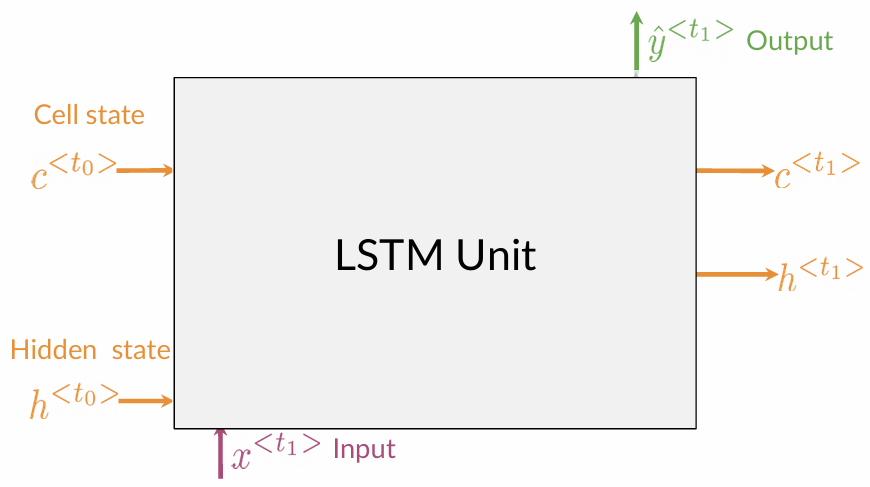

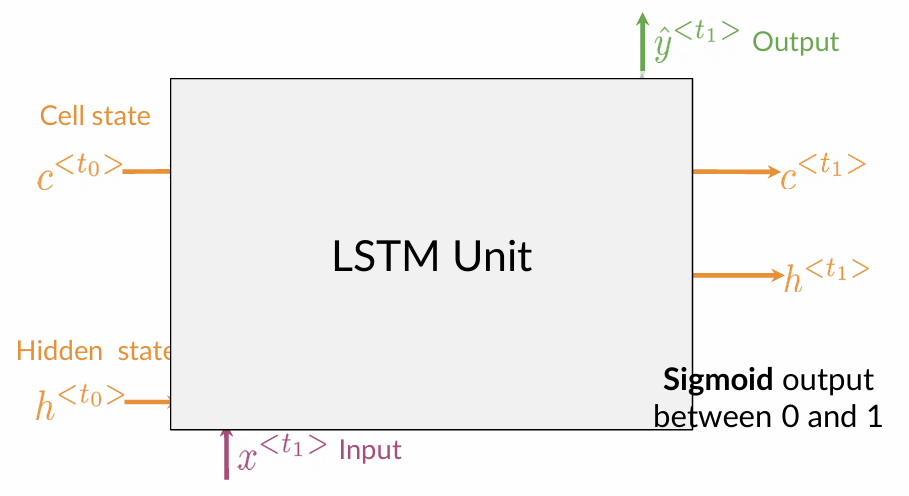

### Candidate Cell State

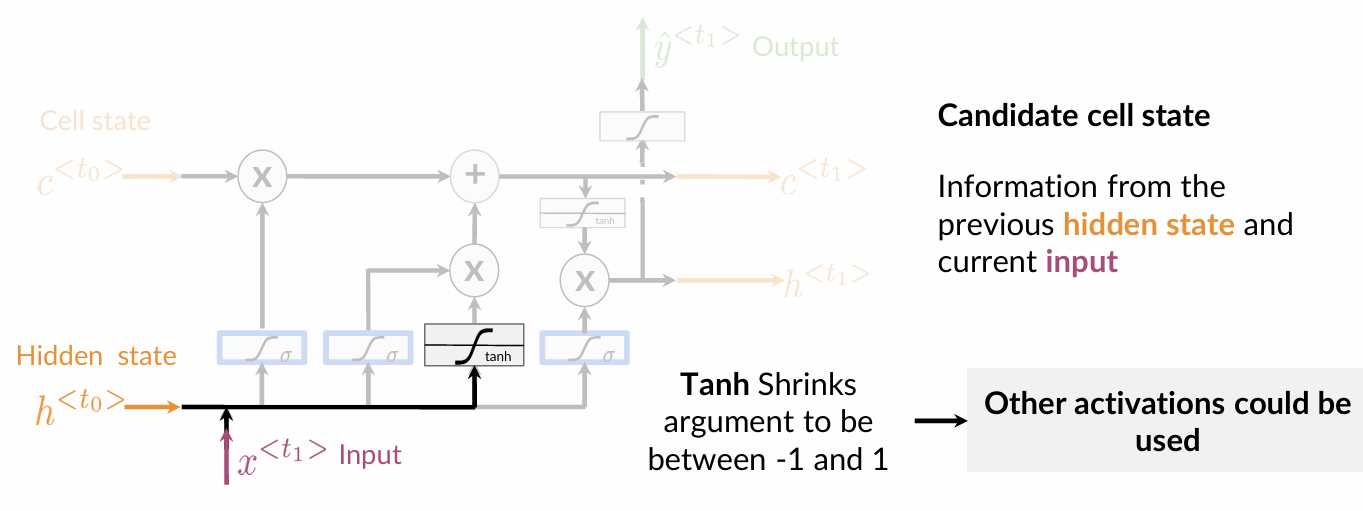

### New Cell State

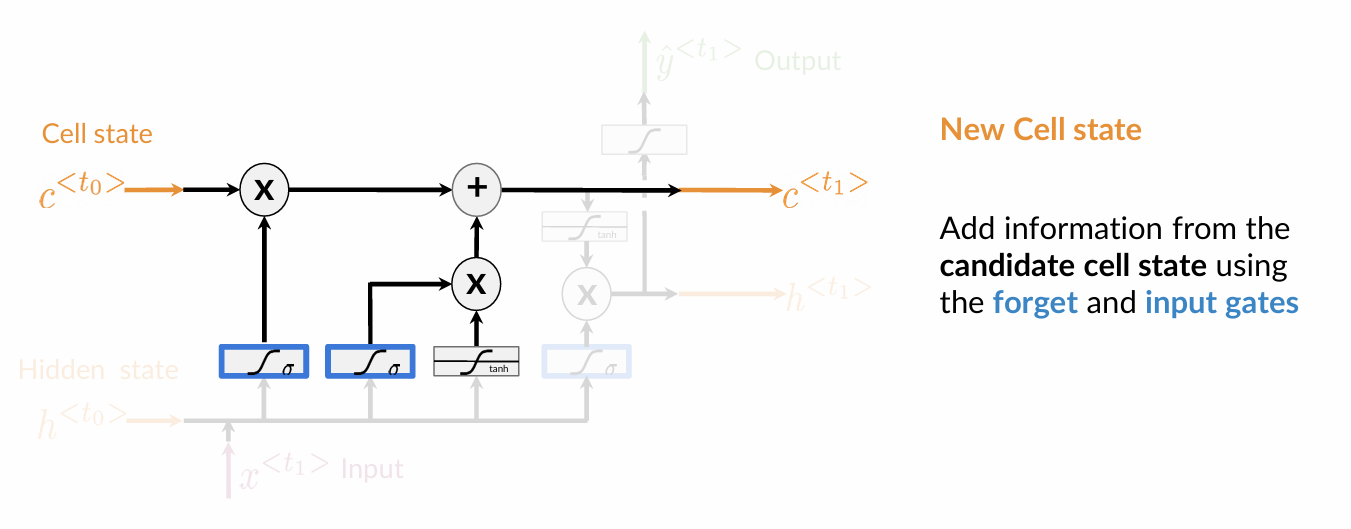

### New Hidden State

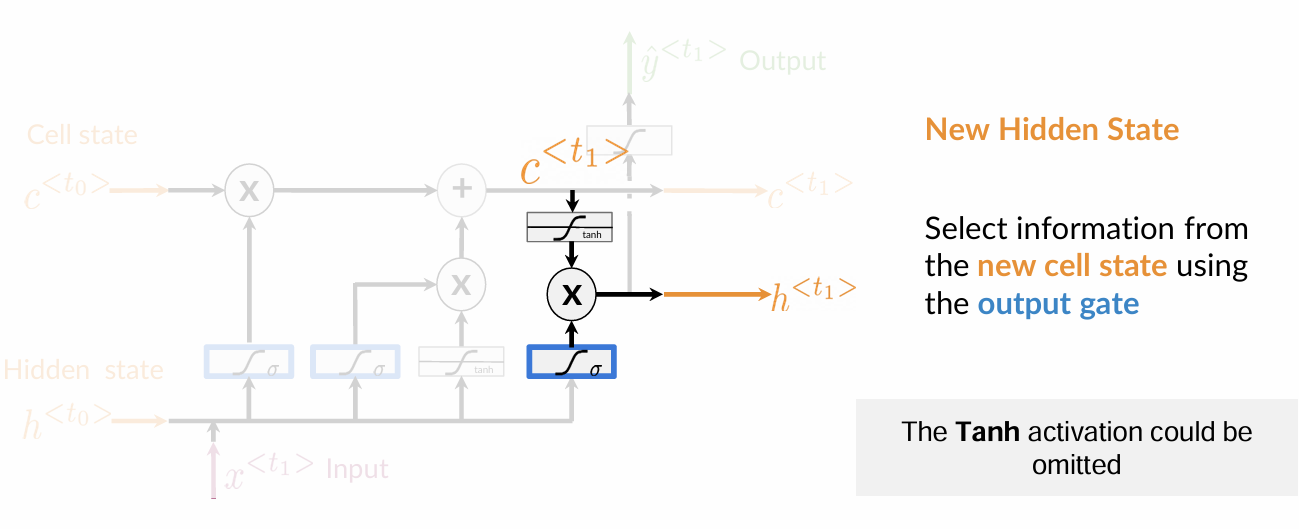

### Summary of LSTM Architecture

LSTMs use a series of gates to decide which information to keep:
- Forget gate decides what to keep
- Input gate decides what to add
- Output gate decides what the next hidden state will be

### Named Entity Recognition (NER) --- Application
- Locates and extracts predefined entities from text
- Places, organizations, names, time and date

>**Many-to-many** problem as multiple words of a sentences are labeled as named entities.

Applications of NER systems
- Search engine efficiency
- Recommendation engines
- Customer service
- Automatic trading




#### Types of Named Entities

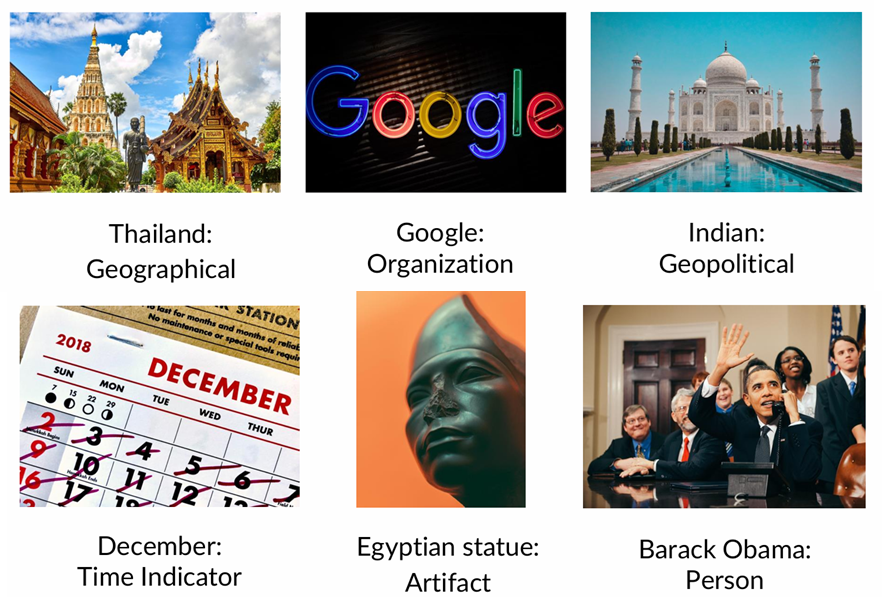

### Labeled Sentence (Example)

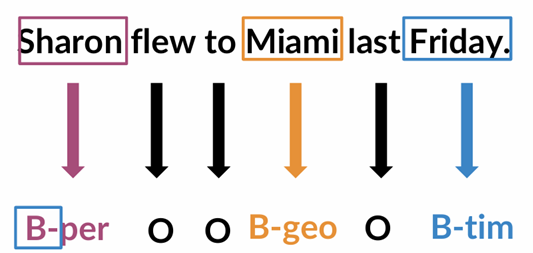

## BIO Tagging Scheme (IOB) in NER

The **BIO format** (also known as **IOB**) is a standard tagging scheme used in **Named Entity Recognition (NER)** to mark the boundaries of entities (such as people, locations, organizations) in text.

It labels each token as:
- **B (Beginning)** of an entity  
- **I (Inside)** an entity  
- **O (Outside)** any entity  

#### BIO Tagging Structure

- **B-<LABEL>**  
  Indicates the **start** of an entity (single-token or multi-token)  
  Example: `B-PER` → beginning of a person name  
- **I-<LABEL>**  
  Indicates the token is **inside** an entity but **not the first token**  
  Example: `I-PER` → continuation of a person name  
- **O**  
  Indicates the token is **not part of any entity**

#### Example Sentence: `"John lives in New York."`

| Token | BIO Tag | Description |
|------|--------|-------------|
| John | B-PER | Beginning of Person |
| lives | O | Outside |
| in | O | Outside |
| New | B-LOC | Beginning of Location |
| York | I-LOC | Inside of Location |
| . | O | Outside |

#### Common NER Entity Types

- **PER** → Person  
- **LOC** → Location  
- **ORG** → Organization  
- **MISC** → Miscellaneous  

```
- Every entity must start with **B-**
- **I-** cannot appear without a preceding **B-** of the same type  
- Consecutive entities of the same type must restart with **B-**
```

### NER using RNN (LSTM/BiLSTM) — Complete Pipeline

| Step | Component | Input | Output | Shape | Description | Example |
|------|----------|-------|--------|-------|------------|---------|
| 1 | Raw Data | Text sentences + NER tags | Tokenized sentences | Variable | Prepare labeled data in BIO format | "John lives in NY" → [B-PER, O, O, B-LOC] |
| 2 | Tokenization | Sentence | Tokens | (L,) | Split sentence into words | ["John","lives","in","NY"] |
| 3 | Vocabulary Creation | Tokens | word2idx mapping | Vocab size | Assign index to each word | {"John":12, "lives":45} |
| 4 | Tag Mapping | Labels | tag2idx mapping | Num_tags | Convert labels to integers | {"B-PER":1, "O":0} |
| 5 | Numerical Encoding | Tokens, tags | Integer sequences | (L,) | Convert words/tags to indices | [12,45,9,78] |
| 6 | Padding | Variable-length sequences | Fixed-length sequences | (N, L) | Pad all N sequences to same length | [12,45,9,0,0] |
| 7 | Masking | Padded sequences | Mask tensor | (N, L) | Ignore padding during training | [1,1,1,0,0] |
| 8 | Embedding Layer | Word indices | Dense vectors | (B, L, E) | Map words to embeddings | "John" → [0.2, -0.1,...] |
| 9 | RNN / LSTM | Embeddings | Contextual features | (B, L, H) | Capture sequence context | Context-aware word vectors |
| 10 | Dropout (optional) | RNN output | Regularized output | (B, L, H) | Prevent overfitting | Random neuron drop |
| 11 | Dense Layer (TimeDistributed) | Hidden states | Logits per token | (B, L, T) | Transformation for each word by applying same dense layer to every time step | Each word → tag scores |
| 12 | Softmax | Logits | Probabilities | (B, L, T) | Convert scores to probabilities | [0.1, 0.8, 0.1] |
| 13 | Loss Function | Predictions + labels | Scalar loss | (1,) | Cross-entropy loss (mask PAD tokens) | Compare predicted vs true tags |
| 14 | Backpropagation (BPTT) | Loss | Gradients | — | Update model weights | Gradients flow through time |
| 15 | Data Generator | Dataset | Batches | (B, L) | Efficient data loading | Batch of 32 sentences |
| 16 | Training Loop | Batches | Updated model | — | Iterate epochs | Forward + backward pass |
| 17 | Inference | New sentence | Predicted tags | (L,) | Predict NER labels | "Ali lives in Paris" → PER, LOC |
| 18 | Post-processing | Tag indices | Label names | (L,) | Convert back to BIO tags | [1,0,0,3] → B-PER,... |
| 19 | Evaluation | Predictions + ground truth | Metrics | — | Measure performance | Precision, Recall, F1 |

> **Note**: When we use padding, we have to mask these paddings tokens to compute accuracy.

**Pretrained Embeddings** (Optional) from CBOW, GloVe, FastText, etc. for better semantic understanding
Pretrained embeddings are usually frozen during the training of RNN/LSTM.

### Transfer Learning

* Complex DL models require **large datasets** with millions of training data points. Suppose we want to build a DL model for object detection in images, but we have a small dataset of a few thousand images.
* **Training a complex model** on the available data might not be a good idea due to the insufficiency of the data.
* The model is likely to overfit the data and might provide **poor generalization** results on test data.


> In contrast to traditional ML/DL, which work in isolation for each problem,**transfer learning** allows us to use knowledge gained from one model to be used in a new but similar task.


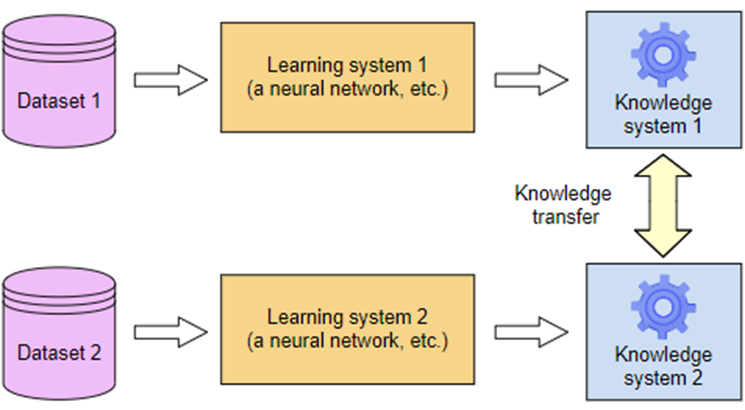


* In **neural networks**, transfer learning stores the gained knowledge (network parameters) from training a large neural network (ImageNet Classification) and applies it to a different but related problem (Classification of flower species from given images).

### Transfer Learning in Neural Networks (NNs)

* Training large-scale datasets, such as the 1000-class ImageNet Large Scale Visual Recognition Challenge (ILSVRC) dataset, requires huge memory and computational resources.
* Because of transfer learning, we don’t need to train networks from scratch for their particular problem.
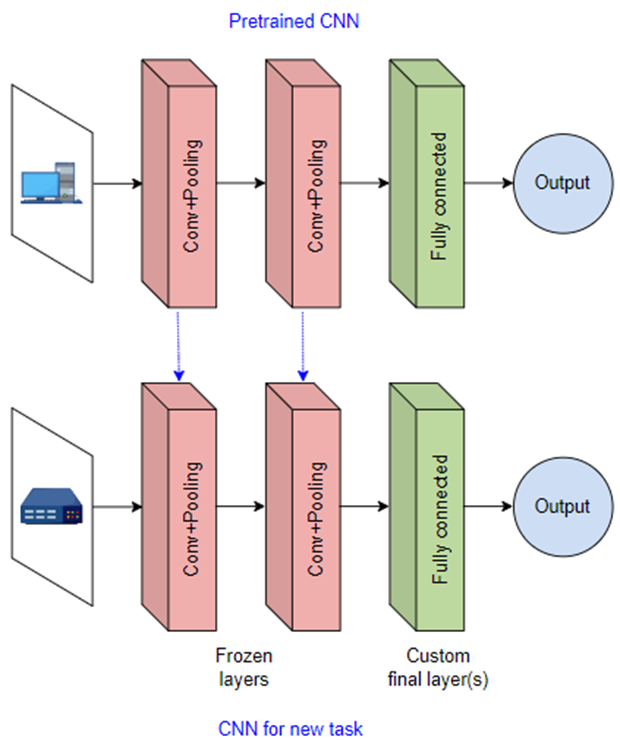


**Steps to Perform Transfer Learning**

1. **Select a pretrained publicly available source model**: Trained on large datasets.
2. **Freeze the weights**: Freeze the weights of earlier layers of the model so that the learning algorithm doesn’t update them.
3. **Fine-tune the source model**: By optionally adding output layers and learning the weights of these layers.

https://www.tensorflow.org/tutorials/images/transfer_learning

### Benefits of Transfer Learning in Neural Networks (NNs)

State-of-the-art publicly available models can be used for transfer learning:
* Residual Network (ResNet)
* MobileNet
* VGG
* Inception
* Word2Vec

Benefits include:
* **Fast learning**: Due to the use of an already trained network.
* **Less training data required**: For the new task.
* **Accurate prediction**: Especially when the transferred knowledge is relevant to our problem.

